In [1]:
import numpy as np

In [2]:
!mamba install pandas

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 2.150 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.5    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge
- pip            26.1.2   pyh145f28c_0         conda-forge


In [3]:
!mamba install scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.658 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.5.1      pyhd8ed1ab_0         conda-forge
+ idna                3.19       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ narwhals            2.25.0     pyhcf101f3_0         conda-forge
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ requests            2.34.2     pyhcf101f3_0         conda-forge
+ scikit-learn        1.9.0      np23py313hb9816c2_0  emscripten-forge-4x
+ setuptools        

In [4]:
import matplotlib.pyplot as plt

In [5]:
import pandas as pd

In [6]:
data_set=pd.read_csv("healthcare-dataset-stroke-data.csv",skiprows=1,header=None)
data_set

data_set[9] = pd.to_numeric(data_set[9], errors='coerce')
data_set[9] = data_set[9].fillna(data_set[9].median())

In [7]:
ds_arr=data_set.to_numpy()
Y_correct=ds_arr[:,11]
ds_arr=np.delete(ds_arr,11,axis=1)


In [8]:
gender=np.zeros((ds_arr.shape[0],3),dtype=int)

for i in range(ds_arr.shape[0]):
    if ds_arr[i,1]=="Male":
        gender[i]=[1,0,0]
    elif ds_arr[i,1]=="Female":
        gender[i]=[0,1,0]
    elif ds_arr[i,1]=="Other":
        gender[i]=[0,0,1]
        
for i in range(ds_arr.shape[0]):
    if ds_arr[i,5]=="Yes":
        ds_arr[i,5]=1
    elif ds_arr[i,5]=="No":
        ds_arr[i,5]=0
        
wk_type=np.zeros((ds_arr.shape[0],5),dtype=int)
for i in range(ds_arr.shape[0]):
    if ds_arr[i,6]=="children":
        wk_type[i]=[1,0,0,0,0]
    elif ds_arr[i,6]=="Govt_job":
        wk_type[i]=[0,1,0,0,0]
    elif ds_arr[i,6]=="Never_worked":
        wk_type[i]=[0,0,1,0,0]
    elif ds_arr[i,6]=="Private":
        wk_type[i]=[0,0,0,1,0]
    elif ds_arr[i,6]=="Self-employed":
        wk_type[i]=[0,0,0,0,1]

for i in range((ds_arr.shape[0])):
    if ds_arr[i,7]=="Rural":
        ds_arr[i,7]=1
    elif ds_arr[i,7]=="Urban":
        ds_arr[i,7]=0

smk_status=np.zeros((ds_arr.shape[0],4),dtype=int)
for i in range(ds_arr.shape[0]):
    if ds_arr[i,10]=="formerly smoked":
        smk_status[i]=[1,0,0,0]
    elif ds_arr[i,10]=="never smoked":
        smk_status[i]=[0,1,0,0]
    elif ds_arr[i,10]=="smokes":
        smk_status[i]=[0,0,1,0]
    elif ds_arr[i,10]=="Unknown":
        smk_status[i]=[0,0,0,1]
        
X=np.delete(ds_arr,[0,1,6,10],axis=1)
X_final=np.hstack((X,wk_type,smk_status,gender))
X_refined=np.delete(X_final,[11,12,16],axis=1)

X_correct=X_refined.astype(np.float64)
Y_correct=Y_correct.astype(np.float64)
X_correct.dtype

dtype('float64')

In [9]:
rng=np.random.default_rng(42)
perm=rng.permutation(X_correct.shape[0])

X_correct,Y_correct=X_correct[perm],Y_correct[perm] 

X_correct.shape


(5110, 16)

In [10]:
X_train=X_correct[:3577,:]
Y_train=Y_correct[:3577]

X_cv=X_correct[3577:4344,:]
Y_cv=Y_correct[3577:4344]

X_test=X_correct[4344:,:]
Y_test=Y_correct[4344:]





In [11]:
mu=np.mean(X_train,axis=0)
sigma=np.std(X_train,axis=0)

X_train_normalized=(X_train-mu)/sigma
X_cv_normalized=(X_cv-mu)/sigma
X_test_normalized=(X_test-mu)/sigma


X_train_normalized.shape




(3577, 16)

In [12]:
def gradient(iters=1000,alpha=0.05):
    W1=np.random.randn(8, X_train_normalized.shape[1]) * 0.01
    b1=np.zeros((8,1))

    W2=np.random.randn(1, 8) * 0.01
    b2=np.zeros((1,1))
    Y_train_reshaped=Y_train.reshape(1,-1)
    cost_history=[]
    for i in range(iters):
        Z1=np.dot(W1,X_train_normalized.T)+b1
        A=np.maximum(0,Z1)
        Z2=np.dot(W2,A)+b2
        Y=1/(1+np.exp(-Z2))

        
        J=1/(X_train_normalized.shape[0])*np.sum(-Y_train_reshaped*np.log(Y)-(1-Y_train_reshaped)*np.log(1-Y))
        cost_history.append(J)

        
        dZ2=Y-Y_train_reshaped
        dW2=1/(X_train_normalized.shape[0])*np.dot(dZ2,A.T)
        db2=1/(X_train_normalized.shape[0])*np.sum(dZ2,axis=1,keepdims=True)

        dZ1=np.dot(W2.T,dZ2)* (Z1>0)
        dW1=1/(X_train_normalized.shape[0])*np.dot(dZ1,X_train_normalized)
        db1=1/(X_train_normalized.shape[0])*np.sum(dZ1,axis=1,keepdims=True)

        W2-=alpha*dW2
        b2-=alpha*db2

        W1-=alpha*dW1
        b1-=alpha*db1
    
    
    return W1,b1,W2,b2,cost_history
W1,b1,W2,b2,cost_history=gradient()



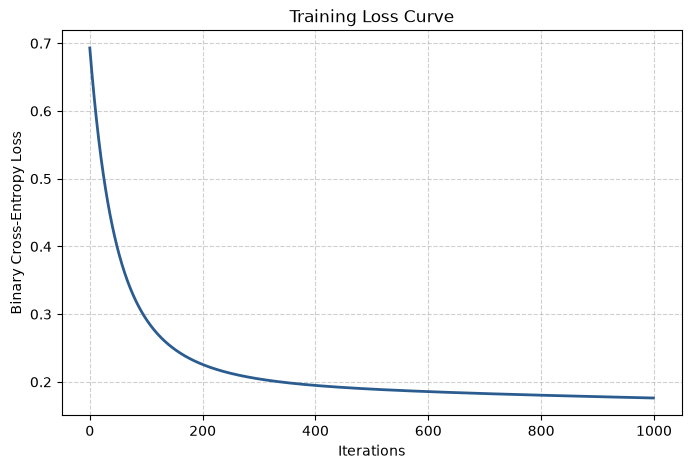

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history, color="#2b5c8f", linewidth=2)
plt.title("Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [14]:
best_f1 = -1.0
best_params = None

thresholds_to_try = np.arange(0.02, 0.51, 0.02)

for lr_try in [0.01, 0.05, 0.1, 0.3]:
    for iters_try in [2000, 5000, 10000]:
        W1_try, b1_try, W2_try, b2_try, _ = gradient(iters=iters_try, alpha=lr_try)

       
        Z1 = np.dot(W1_try, X_cv_normalized.T) + b1_try
        A1 = np.maximum(0, Z1)
        Z2 = np.dot(W2_try, A1) + b2_try
        Y_prob = 1 / (1 + np.exp(-Z2))
        cv_true = Y_cv.flatten()

        best_thresh_f1 = -1.0
        best_thresh = None
        best_thresh_metrics = None

        for thresh in thresholds_to_try:
            preds = (Y_prob >= thresh).astype(int).flatten()

            tp = np.sum((cv_true == 1) & (preds == 1))
            fp = np.sum((cv_true == 0) & (preds == 1))
            fn = np.sum((cv_true == 1) & (preds == 0))

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = (
                2 * (precision * recall) / (precision + recall)
                if (precision + recall) > 0
                else 0.0
            )

            if f1 > best_thresh_f1:
                best_thresh_f1 = f1
                best_thresh = thresh
                best_thresh_metrics = (precision, recall)

        precision, recall = best_thresh_metrics
        print(
            f"lr={lr_try:<4}, iters={iters_try:<5}, best_thresh={best_thresh:.2f} "
            f"-> CV Recall={recall:.4f}, Precision={precision:.4f}, F1={best_thresh_f1:.4f}"
        )

        if best_thresh_f1 > best_f1:
            best_f1 = best_thresh_f1
            best_params = (lr_try, iters_try, best_thresh, W1_try, b1_try, W2_try, b2_try)

best_lr, best_iters, best_thresh, W1_best, b1_best, W2_best, b2_best = best_params
print(f"\nBest Params: lr={best_lr}, iters={best_iters}, threshold={best_thresh:.2f} "
      f"with Validation F1 Score={best_f1:.4f}")

lr=0.01, iters=2000 , best_thresh=0.08 -> CV Recall=0.6889, Precision=0.1270, F1=0.2145
lr=0.01, iters=5000 , best_thresh=0.04 -> CV Recall=1.0000, Precision=0.0754, F1=0.1402
lr=0.01, iters=10000, best_thresh=0.08 -> CV Recall=0.8000, Precision=0.2093, F1=0.3318
lr=0.05, iters=2000 , best_thresh=0.08 -> CV Recall=0.6444, Precision=0.2544, F1=0.3648
lr=0.05, iters=5000 , best_thresh=0.16 -> CV Recall=0.4889, Precision=0.3492, F1=0.4074
lr=0.05, iters=10000, best_thresh=0.12 -> CV Recall=0.6222, Precision=0.2240, F1=0.3294
lr=0.1 , iters=2000 , best_thresh=0.14 -> CV Recall=0.5333, Precision=0.2963, F1=0.3810
lr=0.1 , iters=5000 , best_thresh=0.18 -> CV Recall=0.4222, Precision=0.3065, F1=0.3551
lr=0.1 , iters=10000, best_thresh=0.08 -> CV Recall=0.7111, Precision=0.1893, F1=0.2991
lr=0.3 , iters=2000 , best_thresh=0.12 -> CV Recall=0.6444, Precision=0.2214, F1=0.3295
lr=0.3 , iters=5000 , best_thresh=0.20 -> CV Recall=0.3778, Precision=0.3208, F1=0.3469
lr=0.3 , iters=10000, best_thres

In [15]:
def evaluate_model(X, Y_true, W1, b1, W2, b2, threshold=0.5):
    m = X.shape[0]
    Y_target = Y_true.reshape(1, -1)

    Z1 = np.dot(W1, X.T) + b1
    A1 = np.maximum(0, Z1)
    Z2 = np.dot(W2, A1) + b2
    Y_prob = 1 / (1 + np.exp(-Z2))

    loss = -(1 / m) * np.sum(
        Y_target * np.log(Y_prob)
        + (1 - Y_target) * np.log(1 - Y_prob)
    )

    Y_pred = (Y_prob >= threshold).astype(int)
    y_true_flat = Y_target.flatten()
    y_pred_flat = Y_pred.flatten()

    tp = np.sum((y_true_flat == 1) & (y_pred_flat == 1))
    fp = np.sum((y_true_flat == 0) & (y_pred_flat == 1))
    fn = np.sum((y_true_flat == 1) & (y_pred_flat == 0))
    tn = np.sum((y_true_flat == 0) & (y_pred_flat == 0))

    accuracy = (tp + tn) / m
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * (precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    print(f"Evaluation Metrics (Threshold = {threshold})")
    print(f"Loss      : {loss:.4f}")
    print(f"Accuracy  : {accuracy * 100:.2f}%")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}\n")
    return {
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "y_prob": Y_prob,
        "y_pred": Y_pred,
    }

print("Cross-Validation Set Results:")
cv_metrics = evaluate_model(
    X_cv_normalized, Y_cv, W1_best, b1_best, W2_best, b2_best, threshold=best_thresh
)

print("Test Set Results:")
test_metrics = evaluate_model(
    X_test_normalized, Y_test, W1_best, b1_best, W2_best, b2_best, threshold=best_thresh
)
    

Cross-Validation Set Results:
Evaluation Metrics (Threshold = 0.16)
Loss      : 0.1706
Accuracy  : 91.66%
Precision : 0.3492
Recall    : 0.4889
F1 Score  : 0.4074

Test Set Results:
Evaluation Metrics (Threshold = 0.16)
Loss      : 0.1668
Accuracy  : 88.77%
Precision : 0.1711
Recall    : 0.3611
F1 Score  : 0.2321



In [16]:
from sklearn.neural_network import MLPClassifier

sk_model = MLPClassifier(
    hidden_layer_sizes=(8,),
    activation='relu',
    solver='sgd',
    learning_rate_init=best_lr,
    max_iter=best_iters,
    random_state=42
)
sk_model.fit(X_train_normalized, Y_train)

def evaluate_sklearn(model, X, Y_true, threshold=0.5):
    Y_prob = model.predict_proba(X)[:, 1]
    Y_pred = (Y_prob >= threshold).astype(int)
    y_true_flat = Y_true.flatten()

    tp = np.sum((y_true_flat == 1) & (Y_pred == 1))
    fp = np.sum((y_true_flat == 0) & (Y_pred == 1))
    fn = np.sum((y_true_flat == 1) & (Y_pred == 0))
    tn = np.sum((y_true_flat == 0) & (Y_pred == 0))

    accuracy = (tp + tn) / len(y_true_flat)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * (precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    print(f"sklearn MLPClassifier (Threshold = {threshold})")
    print(f"Accuracy  : {accuracy * 100:.2f}%")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}\n")
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

print("sklearn — CV Results:")
sk_cv_metrics = evaluate_sklearn(sk_model, X_cv_normalized, Y_cv, threshold=best_thresh)

print("sklearn — Test Results:")
sk_test_metrics = evaluate_sklearn(sk_model, X_test_normalized, Y_test, threshold=best_thresh)

print("\n From-Scratch vs sklearn (Test Set)")
print("Precision - From-Scratch:", round(test_metrics['precision'], 4))
print("Precision - sklearn:     ", round(sk_test_metrics['precision'], 4))
print("Recall    - From-Scratch:", round(test_metrics['recall'], 4))
print("Recall    - sklearn:     ", round(sk_test_metrics['recall'], 4))
print("F1        - From-Scratch:", round(test_metrics['f1'], 4))
print("F1        - sklearn:     ", round(sk_test_metrics['f1'], 4))

sklearn — CV Results:
sklearn MLPClassifier (Threshold = 0.16)
Accuracy  : 89.83%
Precision : 0.2857
Recall    : 0.4889
F1 Score  : 0.3607

sklearn — Test Results:
sklearn MLPClassifier (Threshold = 0.16)
Accuracy  : 89.30%
Precision : 0.1290
Recall    : 0.2222
F1 Score  : 0.1633


 From-Scratch vs sklearn (Test Set)
Precision - From-Scratch: 0.1711
Precision - sklearn:      0.129
Recall    - From-Scratch: 0.3611
Recall    - sklearn:      0.2222
F1        - From-Scratch: 0.2321
F1        - sklearn:      0.1633
